In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[1]  # points to IKEA_assembly_guide_assistent/
sys.path.insert(0, str(ROOT))

In [2]:
ROOT

WindowsPath('c:/Users/Kenan/Desktop/IKEA_Project/IKEA_assembly_guide_assistent')

In [3]:

from dotenv import load_dotenv
from pathlib import Path
from backend.ai.pdf_to_imgs_node import PdfToImagesNode
from backend.ai.step_panel_detector_node import DetectStepPanelsNode
from backend.ai.yolo_step_panel_detector import StepPanelDetector
from backend.ai.crop_step_panel_node import CropStepPanelsNode
from backend.ai.final_graph import build_ikea_full_graph

c:\Users\Kenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()


True

In [5]:

def use_agents(path_pdfnode, path_detectornode, path_cropnode, path_to_pdf):
    pdf_node = PdfToImagesNode(
    artifact_root=Path(path_pdfnode),
    dpi=200,
    )

    # --- YOLO detector
    detector = StepPanelDetector(
        weights_path=path_detectornode,
        conf=0.20,
        iou=0.7,
        device="cuda:0",
    )

    detect_node = DetectStepPanelsNode(detector)

    # --- crop node
    crop_node = CropStepPanelsNode(
        artifacts_root=Path(path_cropnode),
        padding_px=16,
        cache_policy="use_cache",
    )

    graph = build_ikea_full_graph(pdf_node, detect_node, crop_node)
    # r"C:\Users\Kenan\Desktop\harvord_ikea\pdfs\Shelf\pinnig\0.pdf"
    state0 = {
        "pdf_source": {"kind": "path", "path": path_to_pdf, "filename": "ikea4.pdf"}
    }

    final_state = graph.invoke(state0, config={"recursion_limit": 200})

    return graph, final_state


In [6]:
pdf_node = PdfToImagesNode(
    artifact_root=Path(r"C:\Users\Kenan\Desktop\IKEA_Project\IKEA_assembly_guide_assistent\artifacts_test"),
    dpi=200,
)

# --- YOLO detector
detector = StepPanelDetector(
    weights_path=r"C:\Windows\System32\runs\detect\train\weights\best.pt",
    conf=0.20,
    iou=0.7,
    device="cuda:0",
)

detect_node = DetectStepPanelsNode(detector)

# --- crop node
crop_node = CropStepPanelsNode(
    artifacts_root=Path(r"C:\Users\Kenan\Desktop\IKEA_Project\IKEA_assembly_guide_assistent\artifacts_test"),
    padding_px=16,
    cache_policy="use_cache",
)

In [7]:
graph = build_ikea_full_graph(pdf_node, detect_node, crop_node)
# r"C:\Users\Kenan\Desktop\harvord_ikea\pdfs\Shelf\pinnig\0.pdf"
state0 = {
    "pdf_source": {"kind": "path", "path": r"C:\Users\Kenan\Desktop\harvord_ikea\pdfs\Desk\fredrik\0.pdf", "filename": "ikea4.pdf"}
}

final_state = graph.invoke(state0, config={"recursion_limit": 200})

[INSTRUCTOR] current_step = 0 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 1 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 2 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 3 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 4 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 5 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 6 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 7 len(steps) = 9 has_final = False
[INSTRUCTOR] current_step = 8 len(steps) = 9 has_final = False


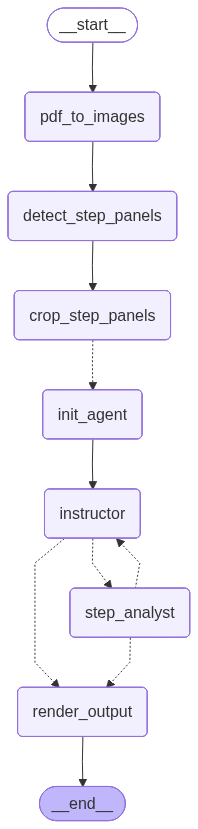

In [8]:
graph

In [9]:
final_state.keys()

dict_keys(['pdf_source', 'pdf_render', 'panel_detections', 'step_crops', 'current_step', 'step_analyses', 'messages', 'final_instructions', 'output_text', 'output_text_list'])

In [10]:
final_state["final_instructions"]["raw"]

'```json\n{\n  "assembly_instructions": [\n    {\n      "step_id": "699432_p002_s00",\n      "action_summary": "Attach end caps to the ends of the horizontal and vertical bars.",\n      "objects": ["horizontal bar", "vertical bar", "end caps"],\n      "fasteners": [],\n      "quantities": {\n        "horizontal bar": 2,\n        "vertical bar": 2,\n        "end caps": 8\n      },\n      "warnings": [],\n      "dependencies": [],\n      "confidence": 0.95\n    },\n    {\n      "step_id": "699432_p002_s01",\n      "action_summary": "Attach the back panel to the frame.",\n      "objects": ["back panel", "frame"],\n      "fasteners": [],\n      "quantities": {\n        "back panel": 1,\n        "frame": 1\n      },\n      "warnings": [],\n      "dependencies": [],\n      "confidence": 0.95\n    },\n    {\n      "step_id": "699432_p003_s00",\n      "action_summary": "Attach the back panel to the frame.",\n      "objects": ["back panel", "frame"],\n      "fasteners": [],\n      "quantities":

In [11]:
final_state.get("final_instructions").get("raw")

'```json\n{\n  "assembly_instructions": [\n    {\n      "step_id": "699432_p002_s00",\n      "action_summary": "Attach end caps to the ends of the horizontal and vertical bars.",\n      "objects": ["horizontal bar", "vertical bar", "end caps"],\n      "fasteners": [],\n      "quantities": {\n        "horizontal bar": 2,\n        "vertical bar": 2,\n        "end caps": 8\n      },\n      "warnings": [],\n      "dependencies": [],\n      "confidence": 0.95\n    },\n    {\n      "step_id": "699432_p002_s01",\n      "action_summary": "Attach the back panel to the frame.",\n      "objects": ["back panel", "frame"],\n      "fasteners": [],\n      "quantities": {\n        "back panel": 1,\n        "frame": 1\n      },\n      "warnings": [],\n      "dependencies": [],\n      "confidence": 0.95\n    },\n    {\n      "step_id": "699432_p003_s00",\n      "action_summary": "Attach the back panel to the frame.",\n      "objects": ["back panel", "frame"],\n      "fasteners": [],\n      "quantities":

In [12]:
final_state["output_text"]

'### Step 1: Attach end caps to the bars\n**You need:**\n- horizontal bar — 2\n- vertical bar — 2\n- end caps — 8\n\n**What to do:**\n- Take the 2 horizontal bars and 2 vertical bars.\n- Attach 2 end caps to each end of the horizontal bars.\n- Attach 2 end caps to each end of the vertical bars.\n\n---\n\n### Step 2: Attach the back panel to the frame\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges carefully to ensure a snug fit.\n- Press the back panel into place on the frame.\n\n---\n\n### Step 3: Attach the back panel to the frame\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges carefully to ensure a snug fit.\n- Press the back panel into place on the frame.\n\n---\n\n### Step 4: Attach the tabletop to the frame using dowels and a hammer\n**You need:**\n- tabletop — 1\n- frame — 1\n- dowels — 4\n\n**What to do:**\n- Insert 

In [13]:
final_state["output_text_list"]

['### Step 1: Attach end caps to the bars\n**You need:**\n- horizontal bar — 2\n- vertical bar — 2\n- end caps — 8\n\n**What to do:**\n- Take the 2 horizontal bars and 2 vertical bars.\n- Attach 2 end caps to each end of the horizontal bars.\n- Attach 2 end caps to each end of the vertical bars.\n\n---',
 '### Step 2: Attach the back panel to the frame\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges carefully to ensure a snug fit.\n- Press the back panel into place on the frame.\n\n---',
 '### Step 3: Attach the back panel to the frame\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges carefully to ensure a snug fit.\n- Press the back panel into place on the frame.\n\n---',
 '### Step 4: Attach the tabletop to the frame using dowels and a hammer\n**You need:**\n- tabletop — 1\n- frame — 1\n- dowels — 4\n\n**What to do:**\n- Ins

### Step 1: Attach end caps to the ends of the horizontal and vertical beams.\n**You need:**\n- horizontal beam — 2\n- vertical beam — 2\n- end caps — 8\n\n**What to do:**\n- Take the 2 horizontal beams and 2 vertical beams.\n- Attach an end cap to each end of the horizontal and vertical beams.\n- Ensure that all end caps are securely fitted.\n\n### Step 2: Attach the back panel to the frame.\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges of the back panel with the frame.\n- Press the back panel firmly into place.\n\n### Step 3: Attach the back panel to the frame.\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Again, position the back panel against the frame.\n- Ensure the edges are aligned properly.\n- Press the back panel firmly into place.\n\n### Step 4: Attach the tabletop to the frame using dowels and secure with a hammer.\n**You need:**\n- tabletop — 1\n- frame — 1\n- dowels — 2\n\n**What to do:**\n- Insert the 2 dowels into the designated holes on the frame.\n- Align the tabletop with the dowels.\n- Gently tap the tabletop down with a hammer to secure it.\n\n### Step 5: Attach the bracket to the frame.\n**You need:**\n- bracket — 2\n\n**What to do:**\n- Take the 2 brackets and position them on the frame.\n- Ensure they are aligned correctly with the frame.\n- Press down firmly to attach them.\n\n### Step 6: Attach the tabletop frame to the legs.\n**You need:**\n- tabletop frame — 1\n- legs — 2\n- screws — 4\n\n**What to do:**\n- Position the tabletop frame on top of the 2 legs.\n- Use the 4 screws to secure the tabletop frame to the legs.\n- Tighten the screws evenly to ensure stability.\n\n### Step 7: Attach the tabletop to the frame.\n**You need:**\n- tabletop — 1\n- frame — 1\n- screws — 8\n\n**What to do:**\n- Place the tabletop onto the frame.\n- Use the 8 screws to secure the tabletop to the frame.\n- Ensure all screws are tightened evenly for a stable assembly.\n\n### Step 8: Final assembly of the table.\n**You need:**\n- tabletop — 1\n- legs — 2\n- support beam — 1\n\n**What to do:**\n- Position the legs under the tabletop.\n- Attach the support beam between the legs for added stability.\n- Ensure everything is aligned and secure before finishing.

# Assembly Instructions

## Parts & Fasteners

### Parts
**Horizontal Beams**: 2\n- **Vertical Supports**: 2
- **End Caps**: 4
- **Clips**: 4
- **Back Panel**: 2
- **Frame**: 1
- **Tabletop**: 1
- **Tabletop Frame**: 1
- **Legs**: 2
- **Support Beam**: 1
- **Brackets**: 2

### Fasteners
- **Clips**: 4
- **Dowels**: 4
- **Screws**: 12 (4 for tabletop frame to legs, 8 for tabletop to frame)

## Warnings
- Ensure end caps are securely attached using a hammer.

## Steps

1. **Attach End Caps**
   - Attach end caps to the ends of the horizontal beams and secure with clips.
   - Use 4 clips for this step.
2. **Attach Back Panel**   
    - Attach the back panel to the frame.
    - Repeat this step for the second back panel.
    
3. **Attach Tabletop**
   - Attach the tabletop to the frame using dowels and a hammer.
   - Use 4 dowels for this step.
    
4. **Attach Brackets**
   - Attach two brackets to the frame.

5. **Attach Tabletop Frame to Legs**
   - Attach the tabletop frame to the legs using 4 screws.

6. **Attach Tabletop to Frame**
   - Attach the tabletop to the frame using 8 screws.
   
7. **Final Assembly**
   - Complete the final assembly of the table by attaching the tabletop, legs, and support beam.
   - Ensure all previous assembly steps are completed before this step.

In [13]:
import re

def split_rendered_steps(markdown_text: str) -> list[str]:
    # Split on "### Step X:"
    parts = re.split(r'(?=### Step \d+:)', markdown_text)
    return [p.strip() for p in parts if p.strip()]

In [14]:
splitted = split_rendered_steps(final_state["output_text"])

In [15]:
splitted

['### Step 1: Attach end caps to the ends of the horizontal and vertical beams.\n**You need:**\n- horizontal beam — 2\n- vertical beam — 2\n- end caps — 8\n\n**What to do:**\n- Take the 2 horizontal beams and 2 vertical beams.\n- Attach an end cap to each end of the horizontal and vertical beams.\n- Ensure that all end caps are securely fitted.',
 '### Step 2: Attach the back panel to the frame.\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Position the back panel against the frame.\n- Align the edges of the back panel with the frame.\n- Press the back panel firmly into place.',
 '### Step 3: Attach the back panel to the frame.\n**You need:**\n- back panel — 1\n- frame — 1\n\n**What to do:**\n- Again, position the back panel against the frame.\n- Ensure the edges are aligned properly.\n- Press the back panel firmly into place.',
 '### Step 4: Attach the tabletop to the frame using dowels and secure with a hammer.\n**You need:**\n- tabletop — 1\n- frame — 1\n- dowe